# [LAB-01] 1. 차원축소 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame

# 주성분 분석 패키지
from sklearn.decomposition import PCA

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


## 📚 시청 주택정책팀의 지표 압축 보고

### 당신은 보스턴 시청 주택정책팀의 데이터 분석가입니다.

시 전역 506개 지역의 범죄율·대기오염도·재산세율·교육여건 등 13개 지표와 주택 중위가격을 함께 모아 둔 자료(boston)를 넘겨받았습니다.

그런데 지표들이 서로 심하게 얽혀 있습니다. 세금이 높은 지역은 상업지 비율도 높고 오염도 심한 식이어서, 13개를 그대로 모형에 넣으면 어떤 지표가 집값을 움직이는지 해석이 흔들립니다.

팀장은 "13개를 몇 개의 축으로 압축하되, 그 대가로 무엇을 얼마나 잃는지까지 함께 보고하라"고 했습니다. 압축에 필요한 준비부터 축의 개수, 잃게 되는 정보의 양까지 확인하세요.

### 💻 코드 작성

#### 데이터 가져오기

In [2]:
origin = load_data("boston")
origin.head()

📚 보스턴 인근 지역의 인구·환경·교육·범죄·세금 정보 등을 기반으로 주택의 중위가격(MEDV)을 예측하기 위해 수집된 대표적인 회귀 분석용 주택시장 데이터 (출처: https://www.kaggle.com/datasets/altavish/boston-housing-dataset)

    field    description
--  -------  ---------------------------------------------------------------------------------------------
 0  CRIM     타운별 1인당 범죄율 (Per capita crime rate by town)
 1  ZN       25,000 sqft 이상 주거용 대지 비율 (Proportion of residential land zoned for large lots)
 2  INDUS    비소매 상업구역 비율 (Proportion of non-retail business acres per town)
 3  CHAS     명목형, 찰스강 인접 여부 (Charles River dummy variable: 1 if tract bounds river; 0 otherwise)
 4  NOX      대기 오염 정도 (Nitric oxides concentration, parts per 10 million)
 5  RM       주택당 평균 방(Room) 수 (Average number of rooms per dwelling)
 6  AGE      1940년 이전 건축 비율 (Proportion of owner-occupied units built prior to 1940)
 7  DIS      5개 주요 고용센터까지의 거리 (Weighted distances to five Boston employment centers)
 8  RAD      고속도로 접근성 지수 (Index of accessibility to radial highways)
 9  T

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0,0.538,6.575,65.200,4.090,1,296,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0,0.469,6.421,78.900,4.967,2,242,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0,0.469,7.185,61.100,4.967,2,242,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0,0.458,6.998,45.800,6.062,3,222,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0,0.458,7.147,54.200,6.062,3,222,18.700,396.900,5.330,36.200


#### 압축 대상 지표와 눈금 확인

In [3]:
# 주택 가격(MEDV)은 예측 대상이므로 압축 대상에서 뺀다
x = origin.drop("MEDV", axis=1)
print(f"압축 대상 지표: {x.shape[1]}개")

# 지표별 분산 (눈금이 서로 얼마나 다른지)
x.var().sort_values(ascending=False).head()

압축 대상 지표: 13개


TAX   28404.759
B      8334.752
AGE     792.358
ZN      543.937
RAD      75.816
dtype: float64

#### 눈금을 맞추지 않고 그대로 압축했을 때

In [4]:
no_scale = my_prep.pca(origin, y="MEDV", scale=False, n_components=2, plot=False)

변수 13개 -> 주성분 2개 (누적 설명력 96.9%)


,PC1,PC2
Features,,
CRIM,0.029,-0.007
ZN,-0.044,-0.001
INDUS,0.028,0.005
CHAS,-0.000,0.000
NOX,0.000,-0.000
RM,-0.001,-0.000
AGE,0.084,0.006
DIS,-0.007,-0.000
RAD,0.045,0.009


#### 표준화 후 차원축소

변수 13개 -> 주성분 5개 (누적 설명력 80.7%)


,PC1,PC2,PC3,PC4,PC5
Features,,,,,
CRIM,0.251,-0.315,0.247,0.062,-0.082
ZN,-0.256,-0.323,0.296,0.129,-0.321
INDUS,0.347,0.112,-0.016,0.017,0.008
CHAS,0.005,0.455,0.290,0.816,-0.087
NOX,0.343,0.219,0.121,-0.128,-0.137
RM,-0.189,0.149,0.594,-0.281,0.423
AGE,0.314,0.312,-0.018,-0.175,-0.017
DIS,-0.322,-0.349,-0.050,0.215,-0.099
RAD,0.320,-0.272,0.287,0.132,0.204


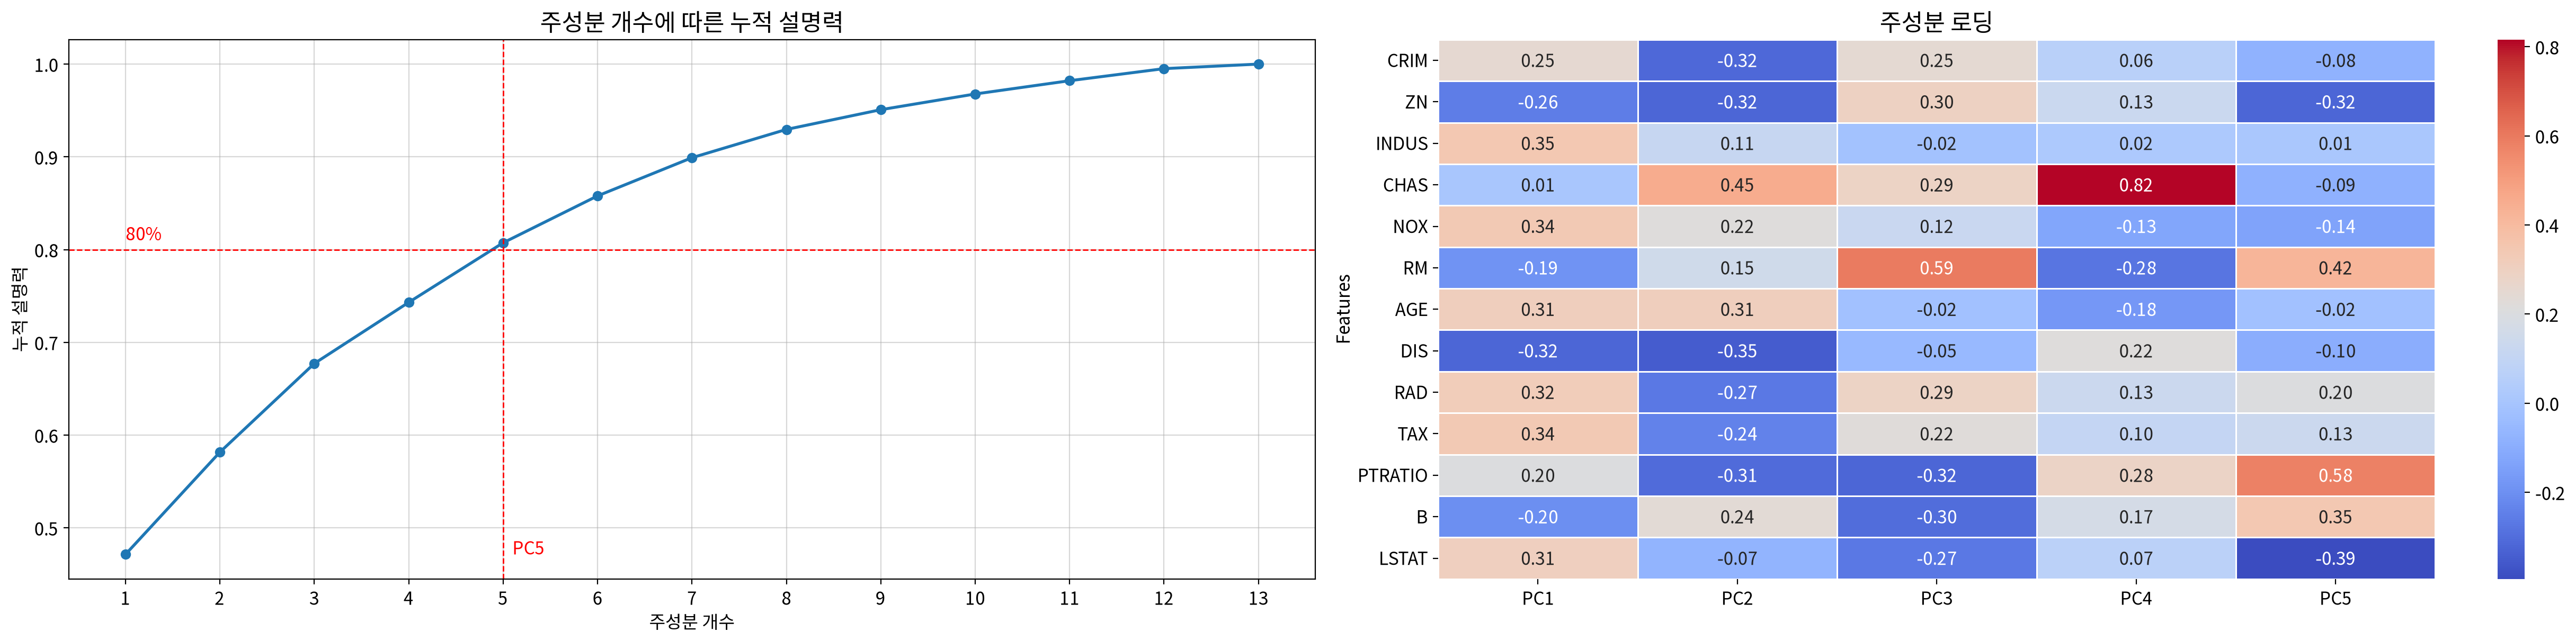

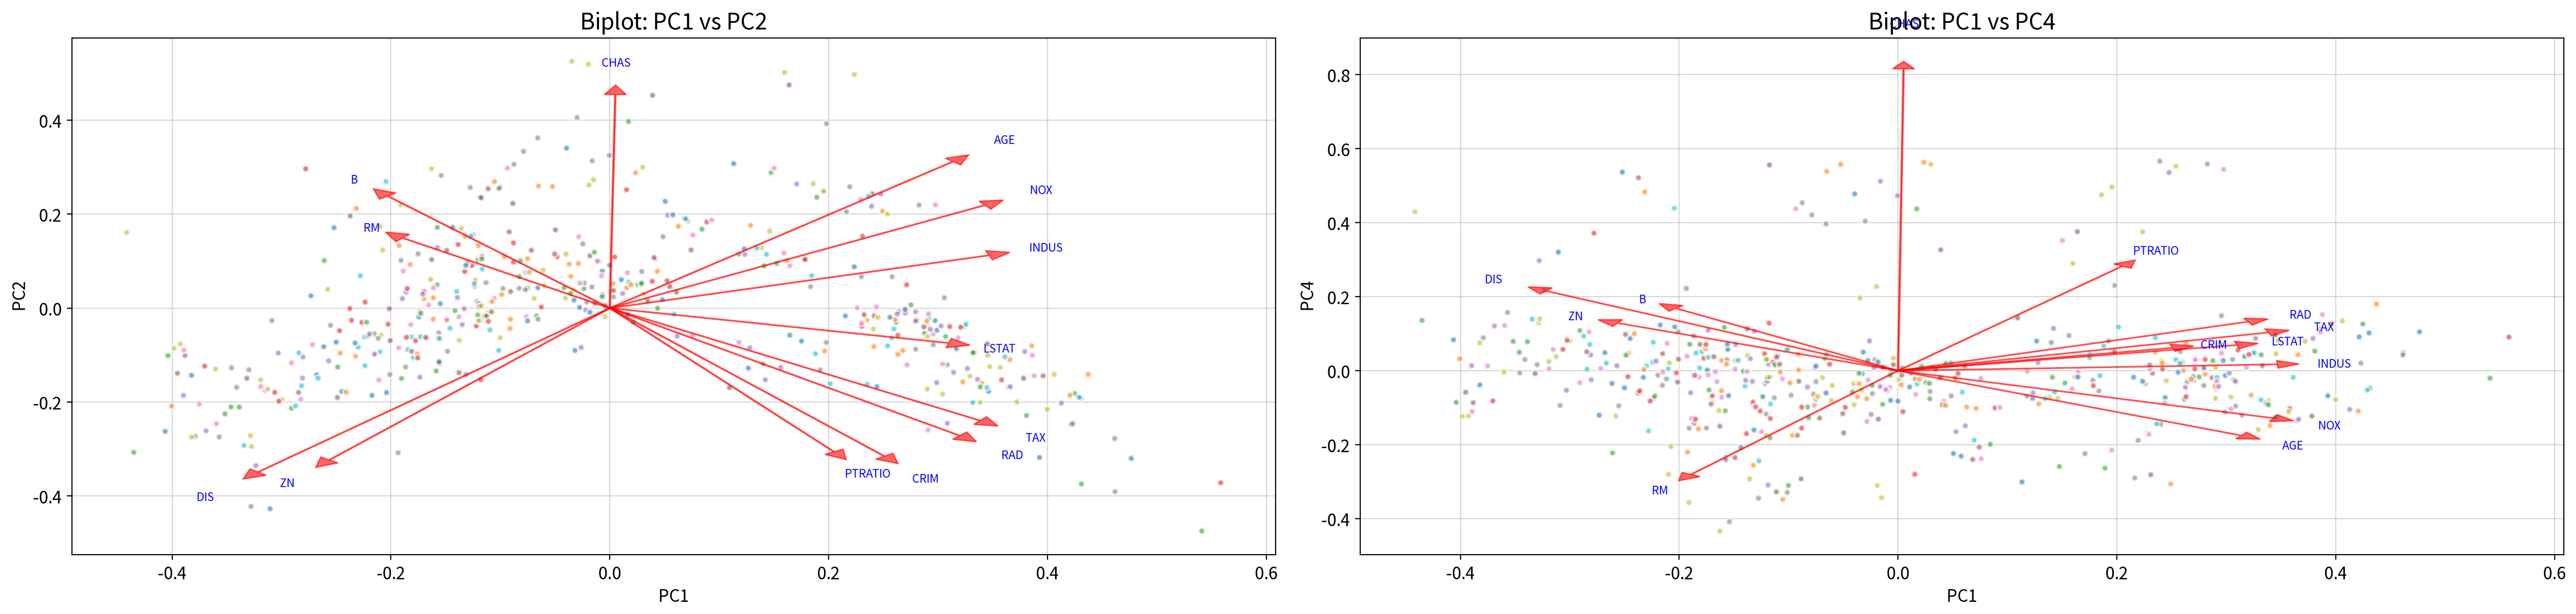

,PC1,PC2,PC3,PC4,PC5,MEDV
0,-2.098,0.773,0.343,-0.892,-0.423,24.000
1,-1.457,0.592,-0.695,-0.487,0.196,21.600
2,-2.075,0.600,0.167,-0.739,0.935,34.700
3,-2.612,-0.007,-0.100,-0.344,1.105,33.400
4,-2.458,0.098,-0.075,-0.428,1.066,36.200


In [5]:
pca_df = my_prep.pca(origin, y="MEDV", biplot=[["PC1", "PC2"], ["PC1", "PC4"]])
pca_df.head()

#### 설명력과 로딩에서 숫자 확정하기

In [6]:
sdf = my_prep.scaling(origin.drop("MEDV", axis=1), verbose=False)
estimator = PCA(n_components=0.8, random_state=RANDOM_STATE).fit(sdf)

cols = [f"PC{i+1}" for i in range(estimator.n_components_)]
loadings = DataFrame(estimator.components_, columns=sdf.columns, index=cols).T

print(f"PC1 설명력: {estimator.explained_variance_ratio_[0]:.3f}")
print(f"채택된 주성분 개수: {estimator.n_components_}개")
print(f"PC1 기여도가 가장 작은 지표: {loadings['PC1'].abs().idxmin()}")
print(f"CHAS의 로딩 절댓값이 가장 큰 주성분: {loadings.loc['CHAS'].abs().idxmax()}")
print(f"버리는 정보 비율: {(1 - estimator.explained_variance_ratio_.sum()) * 100:.1f}%")

loadings.round(3)

PC1 설명력: 0.471
채택된 주성분 개수: 5개
PC1 기여도가 가장 작은 지표: CHAS
CHAS의 로딩 절댓값이 가장 큰 주성분: PC4
버리는 정보 비율: 19.3%


,PC1,PC2,PC3,PC4,PC5
CRIM,0.251,-0.315,0.247,0.062,-0.082
ZN,-0.256,-0.323,0.296,0.129,-0.321
INDUS,0.347,0.112,-0.016,0.017,0.008
CHAS,0.005,0.455,0.290,0.816,-0.087
NOX,0.343,0.219,0.121,-0.128,-0.137
RM,-0.189,0.149,0.594,-0.281,0.423
AGE,0.314,0.312,-0.018,-0.175,-0.017
DIS,-0.322,-0.349,-0.050,0.215,-0.099
RAD,0.320,-0.272,0.287,0.132,0.204
TAX,0.338,-0.239,0.221,0.103,0.130


### 문제 풀이

#### 1. 13개 지표는 재산세율처럼 수백 단위인 것도 있고 대기오염도처럼 0~1 사이인 것도 있습니다. 눈금을 맞추지 않고 그대로 압축하면 첫 번째 축이 사실상 지표 하나의 방향이 되어 버리는데, 그 지표는 무엇인가요?

- **정답**: `TAX`
- **복습 개념**: 차원축소 전에 표준화가 필요한 이유입니다. 주성분은 "분산이 가장 큰 방향"을 찾아 축으로 삼기 때문에, 눈금이 큰 지표는 그 자체로 분산이 커서 축을 독차지하게 됩니다.
- **풀이 접근**: 먼저 지표별 분산을 구해 눈금 차이가 얼마나 큰지 확인합니다. 그 다음 눈금을 맞추지 않은 상태로 압축해서, 첫 번째 축에 각 지표가 얼마나 기여했는지(로딩)를 보면 한 지표만 값이 크게 남는 것을 확인할 수 있습니다.
- **근거(계산 결과)**: 분산은 TAX가 **28,404.76**으로 2위인 B(8,334.75)의 3배가 넘습니다. 실제로 표준화 없이 뽑은 첫 번째 축의 로딩은 TAX가 **0.950**이고 나머지 지표는 대부분 0.1 미만입니다. 즉 이 축은 "13개 지표의 요약"이 아니라 그냥 재산세율입니다.
- **자주 하는 실수**: 표준화 없이 압축했을 때 설명력이 80.6%로 나와서 오히려 잘 압축된 것처럼 보입니다. 하지만 이건 정보를 잘 요약한 것이 아니라, 눈금이 큰 지표 하나가 나머지를 전부 눌러버린 결과입니다. 설명력 숫자만 보고 판단하지 말고 로딩을 함께 확인하세요.

#### 2. 모든 지표의 눈금을 맞춘 뒤 다시 압축했습니다. 첫 번째 축 하나가 13개 지표 전체의 정보 중 차지하는 비율은 얼마인가요? (소수 셋째 자리)

- **정답**: `0.471`
- **복습 개념**: 주성분의 설명력(설명된 분산의 비율)입니다. 표준화하면 모든 지표의 분산이 1로 같아지므로, 전체 정보량은 지표 개수와 같은 13이 되고 각 축은 그중 얼마를 담아냈는지로 평가됩니다.
- **풀이 접근**: 표준화한 자료로 주성분을 뽑은 뒤, 첫 번째 주성분의 설명력을 읽습니다. 로딩표 아래쪽의 설명력 행에서도 같은 값을 볼 수 있습니다.
- **근거(계산 결과)**: 첫 번째 축의 설명력은 **0.471**, 즉 47.1%입니다. 표준화 전의 0.806과 비교하면 크게 떨어졌는데, 눈금 때문에 부풀려졌던 부분이 사라지고 지표들이 실제로 공유하는 공통 구조만 남았기 때문입니다.
- **헷갈리기 쉬운 점**: 설명력이 0.806에서 0.471로 떨어졌으니 표준화 때문에 결과가 나빠졌다고 생각하기 쉽습니다. 반대입니다. 0.806은 재산세율 하나의 눈금이 만든 착시였고, 0.471이 13개 지표가 실제로 함께 움직이는 정도입니다.

#### 3. 누적 설명력이 80%를 처음으로 넘어서는 지점까지만 축을 남기기로 했습니다. 팀장에게 보고할 축의 개수는 몇 개인가요?

- **정답**: `5`
- **복습 개념**: 누적 설명력을 기준으로 주성분 개수를 정하는 방법입니다. 누적 설명력 그래프(스크리 플롯)에서 가로 기준선을 처음 넘어서는 지점이 채택할 개수가 됩니다.
- **풀이 접근**: 각 축의 설명력을 앞에서부터 차례로 더해 나가면서, 그 합이 0.8을 처음 넘어서는 위치가 몇 번째인지 셉니다.
- **근거(계산 결과)**: 누적 설명력은 0.471 → 0.582 → 0.677 → 0.743 → **0.807** 로 쌓입니다. 4개까지는 74.3%로 기준에 못 미치고, **5개**에서 80.7%가 되어 처음 80%를 넘습니다. 13개 지표가 5개 축으로 줄었습니다.
- **함께 생각해 볼 점**: 80%는 정해진 법칙이 아니라 분석가가 잡는 임계점입니다. 90%로 올리면 8개(92.9%)가 필요하고, 70%로 낮추면 4개(74.3%)로 끝납니다. 몇 %로 잡을지는 이 축들을 어디에 쓸 것인지에 따라 실험으로 정해야 합니다.

#### 4. 첫 번째 축은 여러 지표가 함께 움직이는 큰 흐름을 담고 있습니다. 그런데 이 흐름과 사실상 무관해서 기여도가 거의 0인 지표가 하나 있습니다. 어떤 지표인가요?

- **정답**: `CHAS`
- **복습 개념**: 주성분 로딩 벡터 읽기입니다. 로딩은 "원래 지표가 그 축에 얼마나 기여했는가"를 나타내는 가중치이고, 절댓값이 클수록 그 축을 대표하는 지표입니다.
- **풀이 접근**: 로딩표에서 첫 번째 축에 해당하는 열을 세로로 훑어, 절댓값이 가장 작은 지표를 찾습니다. 부호는 방향일 뿐이므로 크기만 비교합니다.
- **근거(계산 결과)**: 첫 번째 축의 로딩에서 CHAS는 **0.005**로 사실상 0입니다. 그다음으로 작은 RM(0.189)과도 차이가 큽니다. 찰스강 인접 여부는 0과 1만 갖는 이진 지표라서, 범죄율·오염도·세금처럼 연속적으로 함께 오르내리는 지표들이 만든 흐름에 얹히지 않습니다.
- **실무 포인트**: 로딩이 0에 가깝다는 것은 "그 지표가 쓸모없다"가 아니라 "이 축으로는 그 지표를 설명하지 못한다"는 뜻입니다. 첫 번째 축만 보고 지표를 버리면 안 됩니다. 바이플롯에서도 CHAS 화살표만 유독 짧게 보이는 이유가 여기에 있습니다.

#### 5. 13개 지표를 5개 축으로 줄여 보고할 때, 원래 지표들이 가지고 있던 정보 중 버리게 되는 비율은 몇 %인가요? (% 단위, 소수 첫째 자리)

- **정답**: `19.3`
- **복습 개념**: 누적 설명력의 나머지가 곧 정보 손실률입니다. 차원축소는 공짜가 아니라 "정보 일부를 내주고 변수 개수를 얻는" 거래이므로, 무엇을 얼마나 내줬는지 함께 보고해야 합니다.
- **풀이 접근**: 채택한 축들의 설명력을 모두 더해 유지되는 비율을 구하고, 전체 100%에서 뺍니다.
- **근거(계산 결과)**: 5개 축의 설명력 합은 0.807(80.7%)이므로 100 − 80.7 = **19.3%**를 버리게 됩니다. 버려지는 것은 6번째 이후 축들, 즉 지표들이 서로 공유하지 않는 자잘한 변동입니다.
- **결론**: 팀장에게 보고할 내용은 이렇습니다. 13개 지표를 5개 축으로 줄일 수 있고, 그 대가로 정보의 19.3%를 잃지만 서로 겹치지 않는(상관이 0인) 5개 축을 얻어 모형이 안정됩니다. 다만 축 하나하나가 무슨 뜻인지 한 단어로 설명할 수 없다는 점도 함께 알려야 합니다. 목적이 "어떤 지표가 집값을 올리는가"를 해석하는 것이라면 차원축소는 오히려 쓰지 않는 편이 낫습니다.